# 5.0 Model training - LightGBM - Optuna search


## Imports


In [1]:
import numpy as np
import joblib
import shap
import mlflow
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error
from optuna.importance import get_param_importances
from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL,
    RANDOM_SEED,
    AIR_GENRE_COL,
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.features import GOLDEN_WEEK_FLG
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    shap_fs,
    lgbm_optuna_search,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred, plot_daily_error_overall, plot_daily_error_by_group
from recruit_restaurant_visitor_forecasting.utils import (
    merge_daily_pred,
    get_format,
    optuna_cv_results_to_df,
)
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

2026-02-03 21:41:12.824 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
CV_SPLITS = 5
TEST_SIZE = 0.2
FIRST_ITER_TRIALS = 40
SECOND_ITER_TRIALS = 200
FS_VALID_SIZE = 0.2
USELESS_FEATURES = [
    *[
        VISITORS_NBR_COL + suffix
        for suffix in ["_mean_7", "_mean_14", "_median_7", "_median_28"]
    ],
    GOLDEN_WEEK_FLG,
]
DROP_COLUMNS = [
    AIR_RESTAURANT_ID_COL,
    VISIT_DATE_COL,
    VISITORS_NBR_COL,
    DAY_OF_WEEK_COL,
    CITY_COL,
    AIR_GENRE_COL,
    *USELESS_FEATURES,
]

MODEL_NAME = "lgbm_optuna_recursive"
MODEL_PATH = MODELS_DIR / f"{MODEL_NAME}_model.pkl"

# mlflow.set_experiment(f"recruit_restaurant_visitors_v04")

## Load and prepare

In [3]:
features, labels = load_data()
features = prepare_features(features)
labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [4]:
X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-01-22 00:00:00
Test set dates: 2017-01-23 00:00:00 to 2017-04-22 00:00:00


## Training

In [6]:
def print_best_params(optuna_study):
    print("Best parameters:", optuna_study.best_params)
    print(f"Best score: {optuna_study.best_value:.5f}")

### Iteration 1

In [ ]:
study, model = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=8,
    drop_features=DROP_COLUMNS,
    n_trials=FIRST_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    window_test_size=39,
    mlflow_run_name="study_first_iter"
)
print_best_params(study)

In [8]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
30,"{'num_leaves': 55, 'learning_rate': 0.04285213...",0.148967,0.969571,-1.028952,-0.881667,-0.861728,-0.839292,-1.236216,1
4,"{'num_leaves': 83, 'learning_rate': 0.02173428...",0.150197,0.969582,-1.026795,-0.887149,-0.861988,-0.833096,-1.238881,2
25,"{'num_leaves': 62, 'learning_rate': 0.03983150...",0.151328,0.969892,-1.025912,-0.885465,-0.857865,-0.837841,-1.242375,3
32,"{'num_leaves': 34, 'learning_rate': 0.04297975...",0.145455,0.970210,-1.032479,-0.888137,-0.862782,-0.839485,-1.228167,4
6,"{'num_leaves': 44, 'learning_rate': 0.01369270...",0.151477,0.970650,-1.033814,-0.889047,-0.857594,-0.833112,-1.239683,5


### SHAP feature selection

In [9]:
selected_features, feature_stats = shap_fs(
    X_train,
    y_train,
    model.named_steps["model"],
    drop_features=DROP_COLUMNS,
    test_size=FS_VALID_SIZE,
)

### Iteration 2

In [ ]:
study, model_shap = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=8,
    drop_features=DROP_COLUMNS,
    n_trials=SECOND_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    features_top=selected_features,
    window_test_size=39,
    mlflow_run_name="study_second_iter"
)
print_best_params(study)

In [11]:
cv_results = optuna_cv_results_to_df(study)
cv_results.sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
192,"{'model__max_depth': 5, 'model__learning_rate'...",0.132256,0.951694,0.971805,0.869526,0.865096,0.850304,1.201740,1
190,"{'model__max_depth': 5, 'model__learning_rate'...",0.134628,0.951744,0.972186,0.867334,0.866432,0.846579,1.206191,2
161,"{'model__max_depth': 5, 'model__learning_rate'...",0.134607,0.951990,0.973278,0.865409,0.865159,0.849817,1.206287,3
194,"{'model__max_depth': 5, 'model__learning_rate'...",0.132954,0.952042,0.975125,0.870317,0.864344,0.848048,1.202374,4
191,"{'model__max_depth': 5, 'model__learning_rate'...",0.135388,0.952544,0.973880,0.867570,0.865242,0.847793,1.208238,5


### Scores

In [12]:
y_train_pred = model_shap.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")

Train set metrics:
RMSLE: 0.8519
MAE:  6.7434


In [6]:
y_test_pred, temp_features = recursive_predict(
    model_shap,
    X_test,
    X_train,
    y_train,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively: 100%|██████████| 90/90 [01:49<00:00,  1.22s/it]


In [17]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")


Test set metrics:
RMSLE: 0.8279
MAE:  7.0716


## Graphs

### Optuna importances

In [15]:
get_param_importances(study)

{'n_estimators': np.float64(0.49786421025438676),
 'learning_rate': np.float64(0.37638684884550955),
 'colsample_bytree': np.float64(0.042442236140901715),
 'keep_count': np.float64(0.04044001552943371),
 'subsample': np.float64(0.014216292812751902),
 'min_child_samples': np.float64(0.013210692656049601),
 'num_leaves': np.float64(0.012187938307868332),
 'reg_lambda': np.float64(0.002352459030549681),
 'reg_alpha': np.float64(0.000899306422548707)}

### SHAP explanation

In [53]:
X_test_clean = model_shap.named_steps["feature_dropper"].transform(X_test)
lgbm = model_shap.named_steps["model"]

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_test_clean)

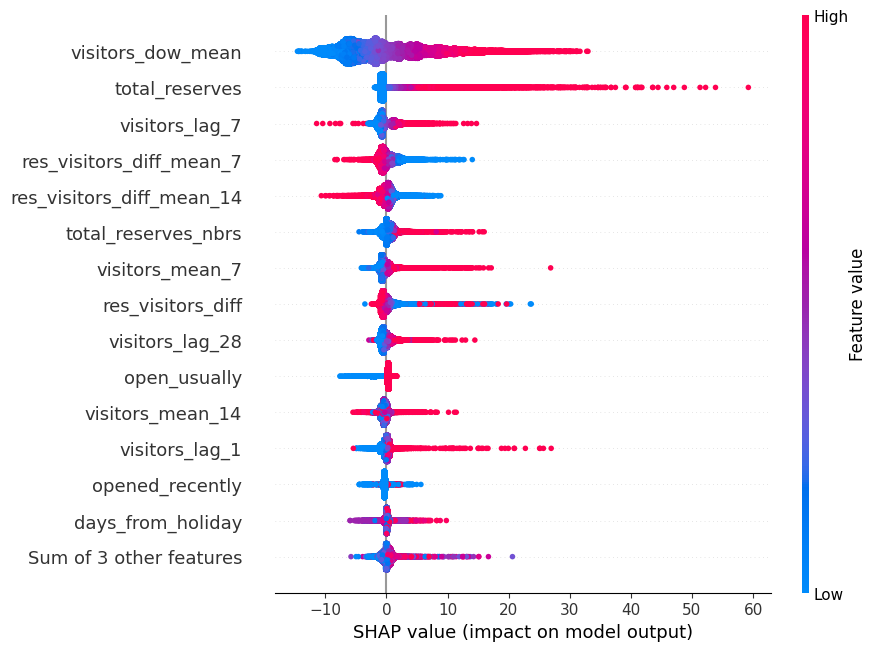

In [54]:
shap.plots.beeswarm(shap_values, max_display=15)

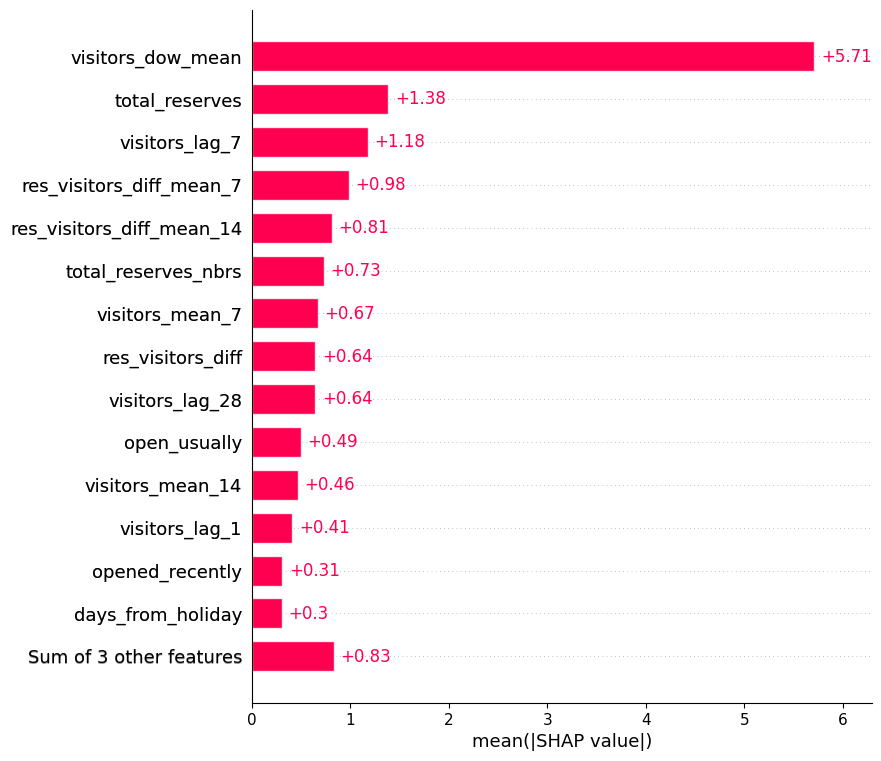

In [55]:
shap.plots.bar(shap_values, max_display=15)

### Visitors per day: actual vs predicted

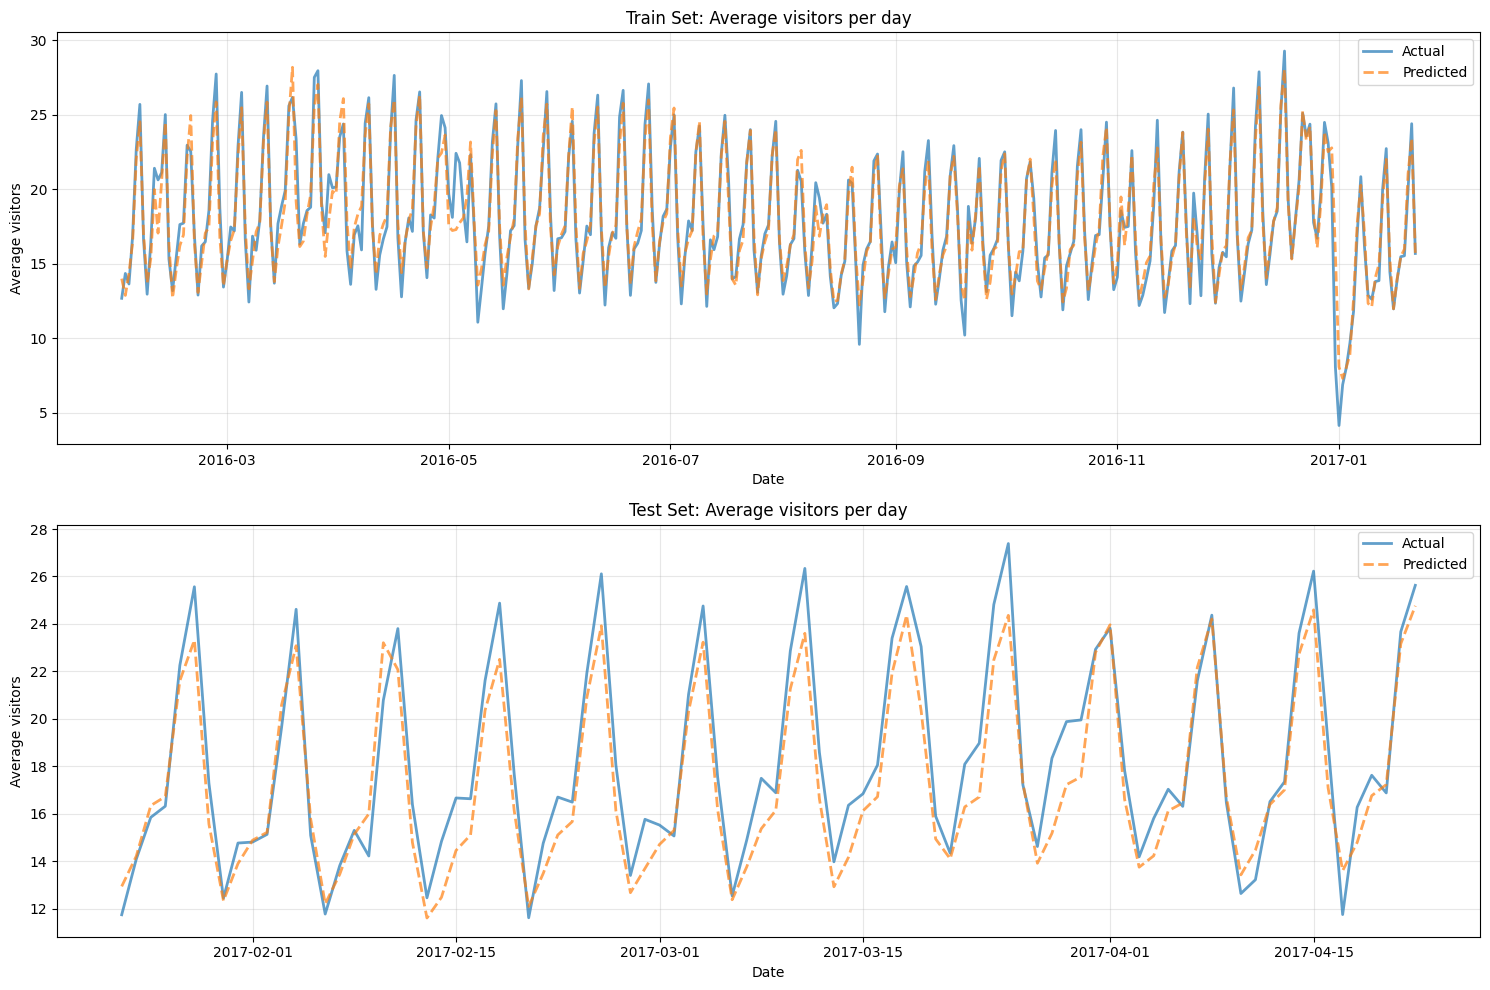

In [56]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

### Residuals

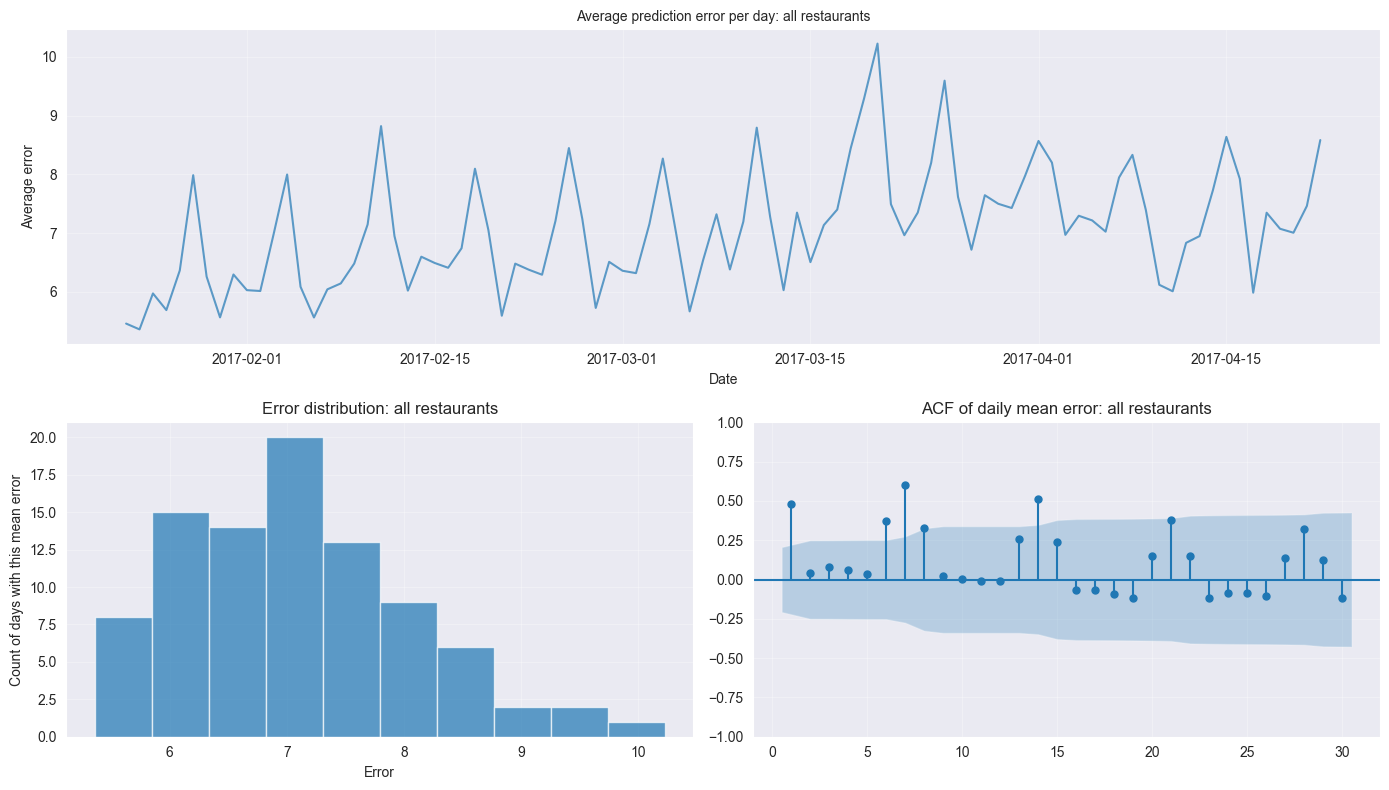

In [7]:
plot_daily_error_overall(X_test, y_test_pred, y_test)

The residuals have some seasonality, so it is likely that some dependence is not taken into account.

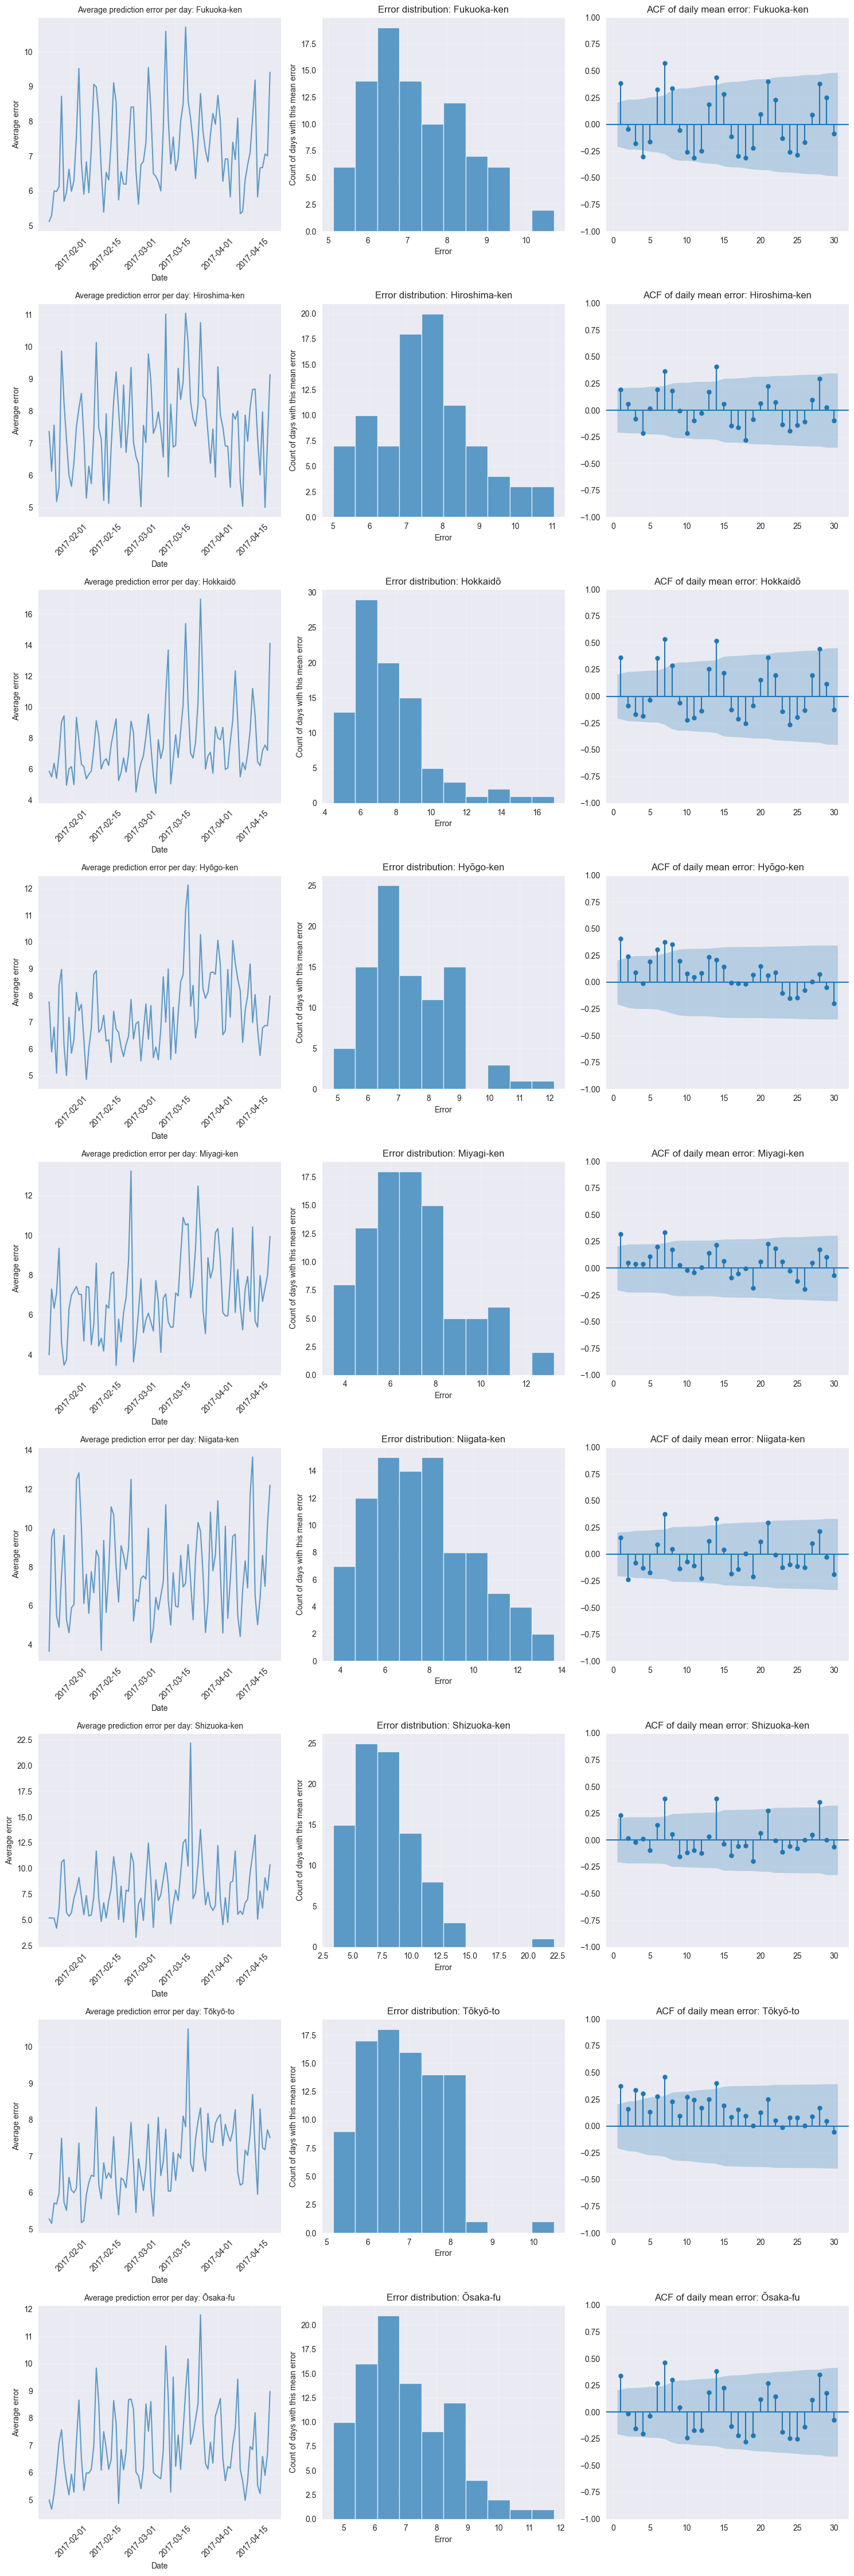

In [8]:
plot_daily_error_by_group(X_test, y_test_pred, y_test, CITY_COL)

The residuals averaged across cities don't differ significantly from each other on average. For most of them, the mean error increases between 2017-03 and 2017-04, but in some cities it's larger, and in others, smaller.

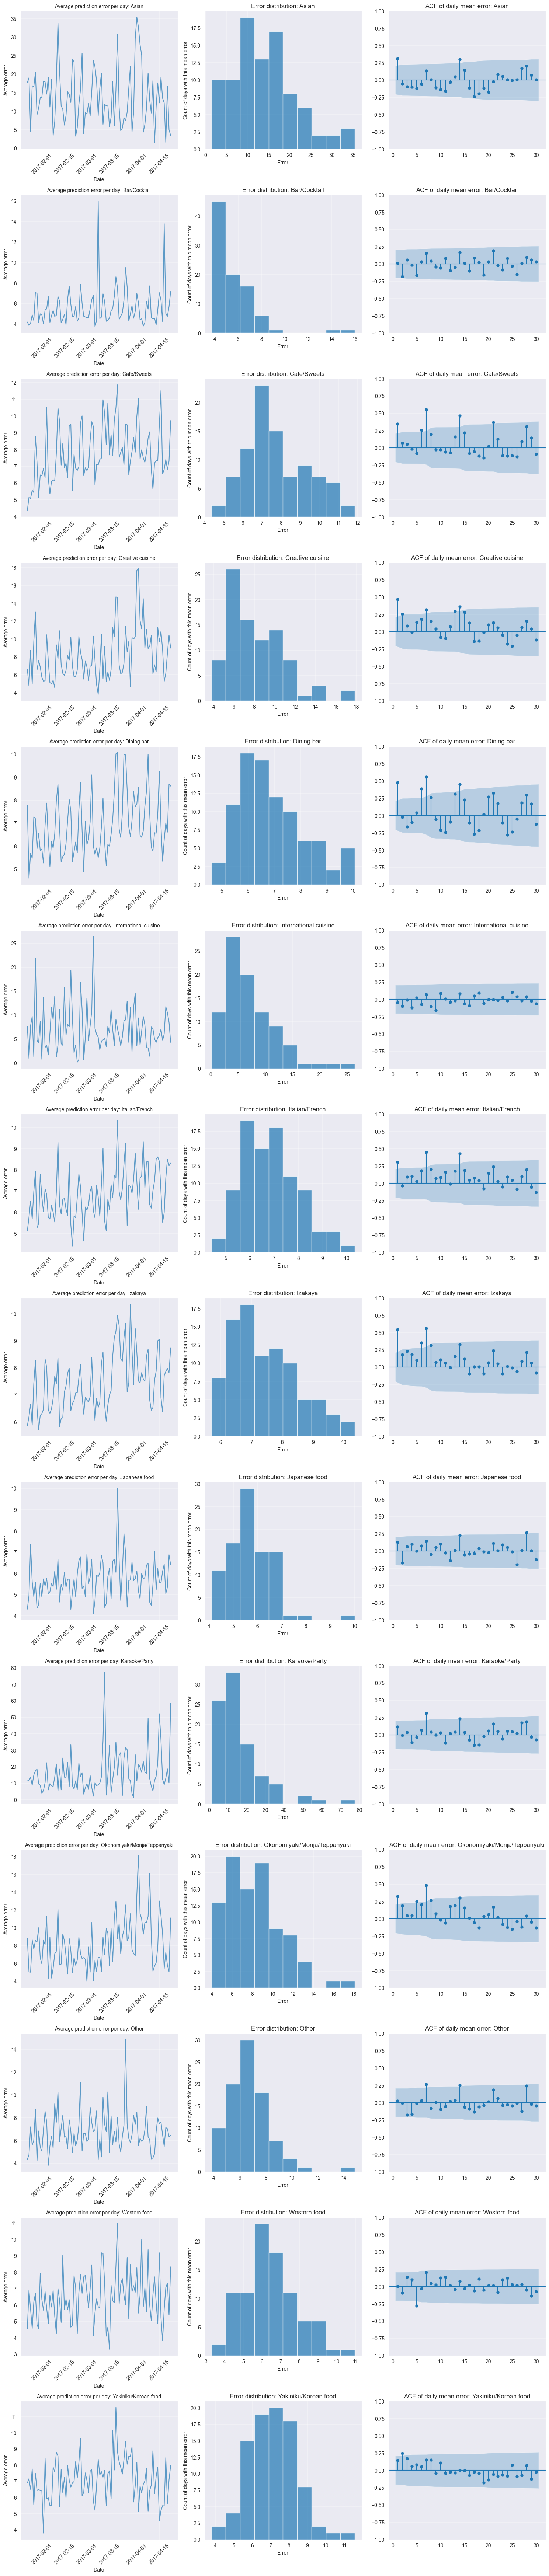

In [9]:
plot_daily_error_by_group(X_test, y_test_pred, y_test, AIR_GENRE_COL)

The largest residuals are observed for restaurants with the Asian and Karaoke/Party genres. However, firstly, the model doesn't consider the genre_te parameter. And if we recall the previous analysis, we see that there are fewer than five restaurants for each of these genres. Creating a different model for them is a questionable idea, but we can try removing the genre with some threshold and retraining the model.

## Testing on future data

In [5]:
model_shap = joblib.load(MODEL_PATH)

In [57]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)
test_features = test_features.reset_index(drop=True)

In [58]:
test_labels, temp_features = recursive_predict(
    model_shap,
    test_features,
    X,
    y,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively: 100%|██████████| 39/39 [00:32<00:00,  1.19it/s]


In [59]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [18]:
with mlflow.start_run(run_name=MODEL_NAME):
    best_cv_result = cv_results.sort_values("rank_test_score").iloc[0].to_dict()
    mlflow.log_dict(
        best_cv_result,
        artifact_file="best_cv_result.json"
    )

    mlflow.log_param("cv_splits", CV_SPLITS)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("feature_selection_validation_size", FS_VALID_SIZE)
    mlflow.log_param("first_iteration_n_trials", FIRST_ITER_TRIALS)
    mlflow.log_param("second_iteration_n_trials", SECOND_ITER_TRIALS)
    mlflow.log_params(best_cv_result["params"])

    mlflow.log_metric("test_rmsle", test_rmsle)
    mlflow.log_metric("cv_mean_test_score", best_cv_result["mean_test_score"])
    mlflow.log_metric("cv_std_test_score", best_cv_result["std_test_score"])

    mlflow.sklearn.log_model(
        sk_model=model_shap,
        name="model"
    )

    mlflow.set_tags({
        "feature_ranking_method": "shap",
        "feature_selection_strategy": "top_k",
        "training_window_size": 39,
        "max_depth": "enabled"
    })

🏃 View run lgbm_optuna_recursive_87_features_union_groups at: http://localhost:5000/#/experiments/6/runs/a2237b146f404a82841153dc632c2578
🧪 View experiment at: http://localhost:5000/#/experiments/6
